Import Libraries such as Pandas, Datasets, Matplotlib.pyplot and Seaborn.

In [1]:
# Importing Libraries
import ast # For string conversion into list object
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # To add percentage sign to y axis ticks

plt.close('all') # close all open plots

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

# How do the top 5 demanded skills trend over the year?

Filter the dataframe to show job postings from the United Kingdom whilst ensuring to create a copy of it also for data integrity.

In [2]:
# Filter df for jobs in United Kingdom
df_UK = df[(df["job_country"] == "United Kingdom")].copy()

Add new column called job_posted_month which extracts the month number from column job_posted_date. This extracted month is to run on the x axis on the final line plot albeit in month-word format.

In [3]:
df_UK["job_posted_month_no"] = df_UK["job_posted_date"].dt.month

df_UK

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,"[python, sql, power bi]","{'analyst_tools': ['power bi'], 'programming':...",10
45,Senior Data Analyst,Senior Data Analyst,"Leeds, UK",via My Stateline Jobs,Full-time,False,United Kingdom,2023-05-30 13:14:08,True,False,United Kingdom,NaN,NaN,NaN,Corecom Consulting,"[sql, python]","{'programming': ['sql', 'python']}",5
74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,NaN,NaN,ttgTalentSolutions,"[sql, r, python, tableau, power bi]","{'analyst_tools': ['tableau', 'power bi'], 'pr...",11
97,Data Analyst,"Systems & Data Analyst - Exploitation, Missing...",United Kingdom,via Totaljobs,Full-time and Contractor,False,United Kingdom,2023-12-04 13:14:01,True,False,United Kingdom,NaN,NaN,NaN,Solihull Metropolitan Borough Council,None,NaN,12
152,Data Scientist,Data Science Team Lead,Anywhere,via OnlyDataJobs,Full-time,True,United Kingdom,2023-12-23 13:12:16,False,False,United Kingdom,NaN,NaN,NaN,StepStone Group,"[react, docker]","{'libraries': ['react'], 'other': ['docker']}",12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785485,Data Analyst,Data Quality Analyst,Anywhere,via LinkedIn,Full-time,True,United Kingdom,2023-10-04 06:09:44,False,False,United Kingdom,NaN,NaN,NaN,Viatris,"[sql, sql server, excel, powerpoint]","{'analyst_tools': ['excel', 'powerpoint'], 'da...",10
785513,Data Scientist,Data Scientist,"Glasgow, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-22 06:21:21,False,False,United Kingdom,NaN,NaN,NaN,ASA Recruitment,"[r, power bi]","{'analyst_tools': ['power bi'], 'programming':...",1
785522,Data Engineer,Lead Data Engineer,"London, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-19 06:16:45,True,False,United Kingdom,NaN,NaN,NaN,bionic-services-ltd,"[sql, python, sql server, aws, snowflake, ssis]","{'analyst_tools': ['ssis'], 'cloud': ['aws', '...",1
785642,Data Engineer,Submission for the position: Data Engineer Sen...,"England, UK",via BAE Systems - Talentify,Full-time,False,United Kingdom,2023-01-02 06:31:23,True,False,United Kingdom,NaN,NaN,NaN,BAE Systems - UK,"[python, vue, ssis, ssrs, qlik, confluence, jira]","{'analyst_tools': ['ssis', 'ssrs', 'qlik'], 'a...",1


As I have made the values in column job_skills from string into list object, they are now 'explodable' and can be exploded into multiple rows. Below they are exploded.

In [4]:
df_UK_exploded = df_UK.explode("job_skills")

df_UK_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,python,"{'analyst_tools': ['power bi'], 'programming':...",10
15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,sql,"{'analyst_tools': ['power bi'], 'programming':...",10
15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,power bi,"{'analyst_tools': ['power bi'], 'programming':...",10
45,Senior Data Analyst,Senior Data Analyst,"Leeds, UK",via My Stateline Jobs,Full-time,False,United Kingdom,2023-05-30 13:14:08,True,False,United Kingdom,NaN,NaN,NaN,Corecom Consulting,sql,"{'programming': ['sql', 'python']}",5
45,Senior Data Analyst,Senior Data Analyst,"Leeds, UK",via My Stateline Jobs,Full-time,False,United Kingdom,2023-05-30 13:14:08,True,False,United Kingdom,NaN,NaN,NaN,Corecom Consulting,python,"{'programming': ['sql', 'python']}",5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785642,Data Engineer,Submission for the position: Data Engineer Sen...,"England, UK",via BAE Systems - Talentify,Full-time,False,United Kingdom,2023-01-02 06:31:23,True,False,United Kingdom,NaN,NaN,NaN,BAE Systems - UK,qlik,"{'analyst_tools': ['ssis', 'ssrs', 'qlik'], 'a...",1
785642,Data Engineer,Submission for the position: Data Engineer Sen...,"England, UK",via BAE Systems - Talentify,Full-time,False,United Kingdom,2023-01-02 06:31:23,True,False,United Kingdom,NaN,NaN,NaN,BAE Systems - UK,confluence,"{'analyst_tools': ['ssis', 'ssrs', 'qlik'], 'a...",1
785642,Data Engineer,Submission for the position: Data Engineer Sen...,"England, UK",via BAE Systems - Talentify,Full-time,False,United Kingdom,2023-01-02 06:31:23,True,False,United Kingdom,NaN,NaN,NaN,BAE Systems - UK,jira,"{'analyst_tools': ['ssis', 'ssrs', 'qlik'], 'a...",1
785676,Senior Data Scientist,Senior Data Scientist,"London, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-22 06:21:23,False,False,United Kingdom,NaN,NaN,NaN,Department for International Development,r,"{'programming': ['r', 'python']}",1


Aggregate the number of each skill posted in each month in a pivot table. Ensure to use fill_value=0 to fill empty cells with 0. I assign this pivot table to the variable df_UK_exploded_pivot.

In [5]:
df_UK_exploded_pivot = df_UK_exploded.pivot_table(
    index="job_posted_month_no",
    columns="job_skills",
    aggfunc="size",
    fill_value=0, # fill empty cells with 0 instead of NaN
    
)

df_UK_exploded_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,arch,asana,asp.net,asp.net core,assembly,...,watson,webex,windows,wire,word,workfront,wrike,wsl,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,209,2,73,8,21,2,2,4,1,5,...,1,0,37,0,105,0,0,1,5,8
2,149,1,48,6,24,1,0,1,0,7,...,12,0,36,0,99,1,0,0,6,5
3,98,0,42,5,17,0,0,1,0,1,...,7,0,21,0,71,0,0,0,3,3
4,98,0,27,4,22,0,0,1,0,1,...,2,0,18,0,45,0,0,0,2,1
5,115,4,23,1,20,0,2,0,0,2,...,4,0,11,0,51,0,0,0,4,8
6,158,0,25,3,18,0,0,1,0,2,...,0,0,4,0,61,0,0,0,6,3
7,181,0,33,1,34,0,1,3,0,5,...,1,0,24,1,73,0,0,0,4,7
8,129,0,29,0,20,0,3,1,0,2,...,0,0,15,4,61,0,0,0,5,6
9,160,2,69,2,43,2,8,4,0,1,...,3,0,39,0,95,0,1,0,4,3


PROBLEM: I want the columns to be in descending order according to the skills which have the highest count (aggregated by size in the pivot table). The columns are currently in alphabetical order.
SOLUTION:  Add a Total row at the bottom of the pivot table. This aggregates the counts of each skill and displays it at the bottom of the pivot table. Then, sort columns in descending order based on the values of this Total row.
Note: I didn't use margins on the pivot table as although they may seem simpler, but, it was returning some errors in the Pandas mechanism. So, I used this workaround instead.  

Add Total row

In [6]:
df_UK_exploded_pivot.loc["Total"] = df_UK_exploded_pivot.sum()

df_UK_exploded_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,arch,asana,asp.net,asp.net core,assembly,...,watson,webex,windows,wire,word,workfront,wrike,wsl,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,209,2,73,8,21,2,2,4,1,5,...,1,0,37,0,105,0,0,1,5,8
2,149,1,48,6,24,1,0,1,0,7,...,12,0,36,0,99,1,0,0,6,5
3,98,0,42,5,17,0,0,1,0,1,...,7,0,21,0,71,0,0,0,3,3
4,98,0,27,4,22,0,0,1,0,1,...,2,0,18,0,45,0,0,0,2,1
5,115,4,23,1,20,0,2,0,0,2,...,4,0,11,0,51,0,0,0,4,8
6,158,0,25,3,18,0,0,1,0,2,...,0,0,4,0,61,0,0,0,6,3
7,181,0,33,1,34,0,1,3,0,5,...,1,0,24,1,73,0,0,0,4,7
8,129,0,29,0,20,0,3,1,0,2,...,0,0,15,4,61,0,0,0,5,6
9,160,2,69,2,43,2,8,4,0,1,...,3,0,39,0,95,0,1,0,4,3


Sort pivot table columns based on Total row in descending order

In [7]:
df_UK_exploded_pivot = df_UK_exploded_pivot[df_UK_exploded_pivot.loc["Total"].sort_values(ascending=False).index]

# Drop the total row as it is not required any more
df_UK_exploded_pivot = df_UK_exploded_pivot.drop("Total")

Convert index numbers (index name is job_posted_month_no) to three-letter month names directly using pandas .to_datetime method.

In [8]:
df_UK_exploded_pivot.index = pd.to_datetime(df_UK_exploded_pivot.index, format='%m').strftime('%b')

In [9]:
df_UK_exploded_pivot

job_skills,sql,python,azure,aws,excel,power bi,r,tableau,spark,gcp,...,asp.net core,nuix,webex,huggingface,heroku,erlang,ionic,pascal,workfront,wrike
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
Jan,2450,2277,972,840,812,709,675,515,497,414,...,1,0,0,0,0,0,0,0,0,0
Feb,1853,1700,808,712,636,555,478,405,380,326,...,0,0,0,0,1,0,0,0,1,0
Mar,1393,1413,623,569,458,434,406,330,307,243,...,0,0,0,0,0,0,0,0,0,0
Apr,995,1031,435,425,309,293,287,218,233,191,...,0,0,0,0,0,0,1,0,0,0
May,1141,1127,473,471,342,336,318,241,220,208,...,0,0,0,0,0,0,0,0,0,0
Jun,1417,1455,612,595,418,418,354,286,335,239,...,0,0,0,0,0,0,0,1,0,0
Jul,1740,1663,823,708,559,595,418,329,366,305,...,0,0,0,0,0,0,0,0,0,0
Aug,1419,1470,621,560,401,402,382,268,297,254,...,0,0,0,0,0,0,0,0,0,0
Sep,2040,1937,845,791,715,658,548,480,392,292,...,0,2,0,1,0,1,0,0,0,1


Create a subset of the data extracting the first 5 columns as they have the highest counts. Extraction is done using the .iloc method.

In [10]:
data_subset = df_UK_exploded_pivot.iloc[:, :5]

data_subset

job_skills,sql,python,azure,aws,excel
job_posted_month_no,,,,,
Jan,2450,2277,972,840,812
Feb,1853,1700,808,712,636
Mar,1393,1413,623,569,458
Apr,995,1031,435,425,309
May,1141,1127,473,471,342
Jun,1417,1455,612,595,418
Jul,1740,1663,823,708,559
Aug,1419,1470,621,560,401
Sep,2040,1937,845,791,715


The subset of data is plotted on a line graph using Matplotlib

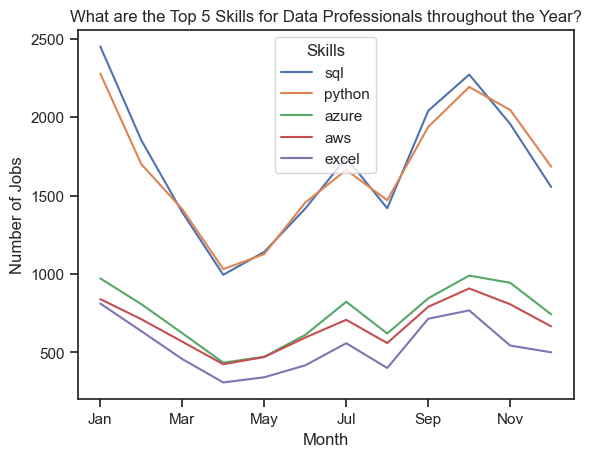

In [18]:
# Plot top 5 skills on line graph using Matplotlib
data_subset.plot(
    kind="line"
)
plt.title("What are the Top 5 Skills for Data Professionals throughout the Year?")
plt.legend(title="Skills")

plt.xlabel("Month")
plt.ylabel("Number of Jobs");

## Plot graph using Seaborn (use a nice theme)

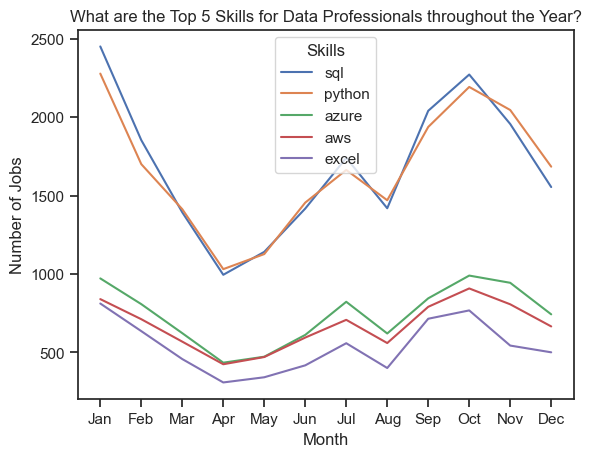

In [12]:
# Plot top 5 skills on line graph using Seaborn

sns.set_theme(style="ticks")

sns.lineplot(
    data=data_subset,
    dashes=False,
)

plt.title("What are the Top 5 Skills for Data Professionals throughout the Year?")
plt.legend(title="Skills"); # Add title to legend

plt.xlabel("Month")
plt.ylabel("Number of Jobs");

# Plot skills on Line Graph based on Percentage

In [13]:
# Return number of jobs posed each month
df_UK_total_jobs = df_UK.groupby("job_posted_month_no").size()

df_UK_total_jobs

job_posted_month_no
1     4781
2     3619
3     2773
4     2094
5     2236
6     2805
7     3187
8     2711
9     4191
10    4664
11    3969
12    3345
dtype: int64

In [14]:
# Make the total_jobs index to match the pivot index format which is month names
df_UK_total_jobs.index = pd.to_datetime(df_UK_total_jobs.index, format='%m').strftime('%b')

# make a percentage pivot with job counts (accessed from pivot table named df_UK_exploded_pivot) and dividing by total jobs
df_UK_percent = df_UK_exploded_pivot.div(df_UK_total_jobs, axis=0) * 100

df_UK_percent


job_skills,sql,python,azure,aws,excel,power bi,r,tableau,spark,gcp,...,asp.net core,nuix,webex,huggingface,heroku,erlang,ionic,pascal,workfront,wrike
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
Jan,51.244510,47.626020,20.330475,17.569546,16.983895,14.829534,14.118385,10.771805,10.395315,8.659276,...,0.020916,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,51.201989,46.974302,22.326610,19.673943,17.573915,15.335728,13.208069,11.190937,10.500138,9.008013,...,0.000000,0.000000,0.000000,0.000000,0.027632,0.000000,0.000000,0.000000,0.027632,0.000000
Mar,50.234403,50.955644,22.466643,20.519293,16.516408,15.650920,14.641183,11.900469,11.071042,8.763072,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,47.516714,49.235912,20.773639,20.296084,14.756447,13.992359,13.705826,10.410697,11.127030,9.121299,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.047755,0.000000,0.000000,0.000000
May,51.028623,50.402504,21.153846,21.064401,15.295170,15.026834,14.221825,10.778175,9.838998,9.302326,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,50.516934,51.871658,21.818182,21.212121,14.901961,14.901961,12.620321,10.196078,11.942959,8.520499,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035651,0.000000,0.000000
Jul,54.596799,52.180734,25.823659,22.215249,17.540006,18.669595,13.115783,10.323188,11.484154,9.570129,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,52.342309,54.223534,22.906677,20.656584,14.791590,14.828477,14.090741,9.885651,10.955367,9.369236,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,48.675734,46.218086,20.162252,18.873777,17.060367,15.700310,13.075638,11.453114,9.353376,6.967311,...,0.000000,0.047721,0.000000,0.023861,0.000000,0.023861,0.000000,0.000000,0.000000,0.023861


In [15]:
data_percentage_subset = df_UK_percent.iloc[:, :5]

data_percentage_subset

job_skills,sql,python,azure,aws,excel
job_posted_month_no,,,,,
Jan,51.244510,47.626020,20.330475,17.569546,16.983895
Feb,51.201989,46.974302,22.326610,19.673943,17.573915
Mar,50.234403,50.955644,22.466643,20.519293,16.516408
Apr,47.516714,49.235912,20.773639,20.296084,14.756447
May,51.028623,50.402504,21.153846,21.064401,15.295170
Jun,50.516934,51.871658,21.818182,21.212121,14.901961
Jul,54.596799,52.180734,25.823659,22.215249,17.540006
Aug,52.342309,54.223534,22.906677,20.656584,14.791590
Sep,48.675734,46.218086,20.162252,18.873777,17.060367


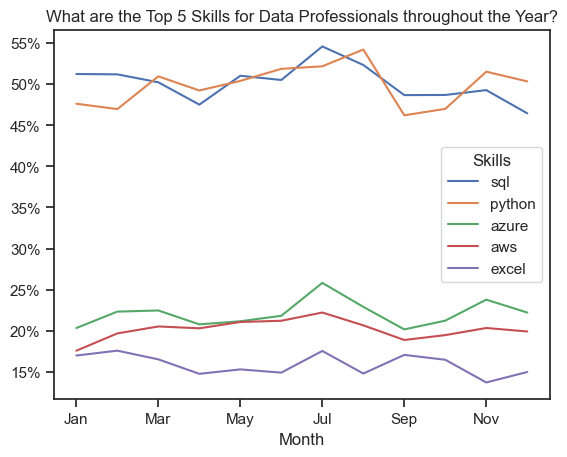

In [16]:
# Plot top 5 skills on line graph using Matplotlib
# Top 5 skills (columns) are accessed with .iloc method
data_percentage_subset.plot(
    kind="line"
)
plt.title("What are the Top 5 Skills for Data Professionals throughout the Year?")
plt.legend(title="Skills") # Gives a proper legend
plt.xlabel("Month")
# plt.ylabel("Percentage of Jobs") commented out as y axis is self-explanatory

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)); # Add percentage sign to y axis ticks

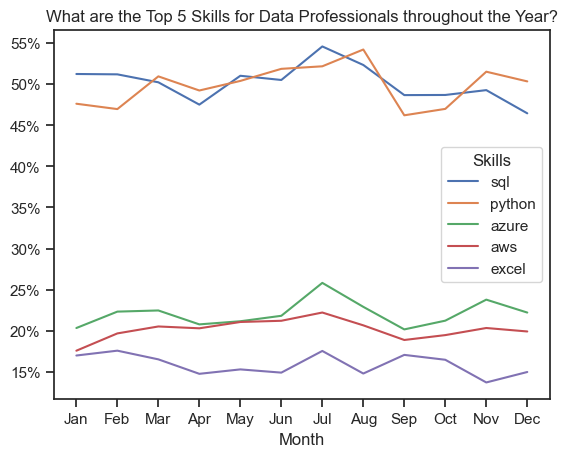

In [17]:
# Plot top 5 skills on line graph using Seaborn
# Top 5 skills (columns) are accessed with .iloc method
sns.lineplot(
    data=data_percentage_subset,
    dashes=False,
)

plt.title("What are the Top 5 Skills for Data Professionals throughout the Year?")
plt.legend(title="Skills"); # Add title to legend
plt.xlabel("Month")
# plt.ylabel("Percentage of Jobs") commented out as y axis is self-explanatory
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)) # Add percentage sign to y axis ticks